# Two-Motor Driving-Strategy Analysis — Full 4-Lap Attempt (Lusail Urban Concept)

Two-motor powertrain — **BLDC 650 W** (acceleration) + **BG 42x45 dCore** (cruise) — with the *rule*
switch (accel on launches/climbs, cruise on flats) and a **gas-and-glide** speed strategy.
**Strategy guidance, not the live car controller.**

**The two stop-and-go points (each a compulsory 3-second stop):**
- **Stop-and-go 1** sits on the **start/finish line**. On **lap 1** it's just the standing start (no stop);
  on **laps 2, 3, 4** the car crosses the line and must stop.
- **Stop-and-go 2** is at ~0.95 km into each lap — happens on **every lap**.

So the attempt has **7 stops**: lap 1 → stop-go 2 only; laps 2–4 → both.

**How to read the colours**
| Colour | Meaning |
|---|---|
| 🟠 orange | BLDC 650 W — acceleration motor |
| 🔵 blue | BG 42x45 dCore — cruise motor |
| 🟢 green | GAS (motor ON) · 🟡 amber GLIDE (coasting) · 🔴 red BRAKE |
| 🟣 purple ★ | stop-and-go 1 (start/finish) |
| ⚫ black ★ | stop-and-go 2 |

Most detail charts use a **steady lap (lap 2)** — representative of laps 2–4, showing **both** stops.
Data: `full_attempt_motor_analysis.csv` (one row per metre, all 4 laps).

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
%matplotlib inline

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#ececea", "grid.linewidth": 0.8,
    "axes.edgecolor": "#9a9a95", "font.size": 11.5,
    "axes.titlesize": 14, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelsize": 12, "figure.facecolor": "white", "axes.facecolor": "white",
    "xtick.color": "#3a3a38", "ytick.color": "#3a3a38", "legend.fontsize": 10,
})

df = pd.read_csv("full_attempt_motor_analysis.csv")

MOTOR_COLORS = {"BLDC 650W": "#eb6834", "BG 42x45 dCore": "#2a78d6"}
PHASE_COLORS = {"gas": "#1a9e4b", "glide": "#eda100", "brake": "#e34948"}
SG1_C, SG2_C = "#6a3d9a", "#111111"                     # stop-go 1 = purple, stop-go 2 = black
START_C = "#0d47a1"                                     # start/finish = big blue square (distinct from stop-and-go 1)
MOTOR_LABEL = {"BLDC 650W": "BLDC 650 W  ·  acceleration motor",
               "BG 42x45 dCore": "BG 42x45 dCore  ·  cruise motor"}
PHASE_LABEL = {"gas": "GAS · motor ON (accelerating)",
               "glide": "GLIDE · motor OFF (coasting)", "brake": "BRAKE"}
ymax = df["v_kmh"].max() * 1.05

# steady lap (lap 2) for the detail views -- has BOTH stop-and-gos
steady = df[df.lap == 2].copy()
lat0, lon0 = steady.latitude.mean(), steady.longitude.mean()
steady["x_m"] = (steady.longitude - lon0) * np.cos(np.radians(lat0)) * 111320.0
steady["y_m"] = (steady.latitude  - lat0) * 111132.0
sg1 = steady[steady.stop_label == "stop-and-go 1"]
sg2 = steady[steady.stop_label == "stop-and-go 2"]

# --- Fixed authoritative track coordinates -> same map projection ---
def _to_xy(lat, lon):
    return ((lon - lon0) * np.cos(np.radians(lat0)) * 111320.0,
            (lat - lat0) * 111132.0)
START_XY = _to_xy(25.48842018, 51.45017025)   # start / finish line
SG1_XY   = _to_xy(25.488390,   51.450116)     # stop-and-go 1
SG2_XY   = _to_xy(25.491948,   51.450453)     # stop-and-go 2
# stop-and-go 1 sits ~6 m from start/finish; nudge its marker up so it renders
# ABOVE the start/finish square (display only -- true position is SG1_XY)
SG1_DISP = (SG1_XY[0], SG1_XY[1] + 95.0)

def mark_stops_map(ax, annotate=True):
    # stop-and-gos shown on every track map, at fixed authoritative coords
    ax.scatter(*SG1_DISP, s=460, marker="*", facecolor=SG1_C, edgecolor="white", linewidths=1.5, zorder=11)
    ax.scatter(*SG2_XY, s=460, marker="*", facecolor=SG2_C, edgecolor="white", linewidths=1.5, zorder=9)
    # start / finish is a separate point (~6 m from stop-and-go 1) with its own marker & colour
    ax.scatter(*START_XY, s=380, marker="s", facecolor=START_C, edgecolor="white", linewidths=1.8, zorder=10)
    # thin leader line: the nudged stop-and-go 1 star actually sits at the start/finish spot
    ax.plot([START_XY[0], SG1_DISP[0]], [START_XY[1], SG1_DISP[1]], color=SG1_C, lw=1.0, ls=":", zorder=8)
    if annotate:
        ax.annotate("START / FINISH", START_XY,
                    textcoords="offset points", xytext=(13, -15), fontsize=10, fontweight="bold", color=START_C)
        ax.annotate("STOP-AND-GO 1", SG1_DISP,
                    textcoords="offset points", xytext=(13, 5), fontsize=10, fontweight="bold", color=SG1_C)
        ax.annotate("STOP-AND-GO 2", SG2_XY,
                    textcoords="offset points", xytext=(13, 3), fontsize=10, fontweight="bold", color=SG2_C)

SG_HANDLES = [
    Line2D([0],[0], marker="s", color="none", markerfacecolor=START_C, markeredgecolor="white",
           markersize=15, label="start / finish line"),
    Line2D([0],[0], marker="*", color="none", markerfacecolor=SG1_C, markeredgecolor="white",
           markersize=17, label="stop-and-go 1  ·  every lap"),
    Line2D([0],[0], marker="*", color="none", markerfacecolor=SG2_C, markeredgecolor="white",
           markersize=17, label="stop-and-go 2  ·  every lap"),
]
print("full attempt:", len(df), "rows |", df.lap.nunique(), "laps | steady lap = lap 2")
print("stops:", df[df.stop_event].stop_label.value_counts().to_dict())

full attempt: 14708 rows | 4 laps | steady lap = lap 2
stops: {'stop-and-go 2': 4, 'stop-and-go 1': 3, 'start (standing)': 1}


## 1 · Full-race speed overview (all 4 laps)

The whole attempt end-to-end. **Purple lines = stop-and-go 1** (start/finish — note it's ABSENT on lap 1),
**black dashed = stop-and-go 2**. Every dip to 0 km/h is a compulsory 3-second stop.

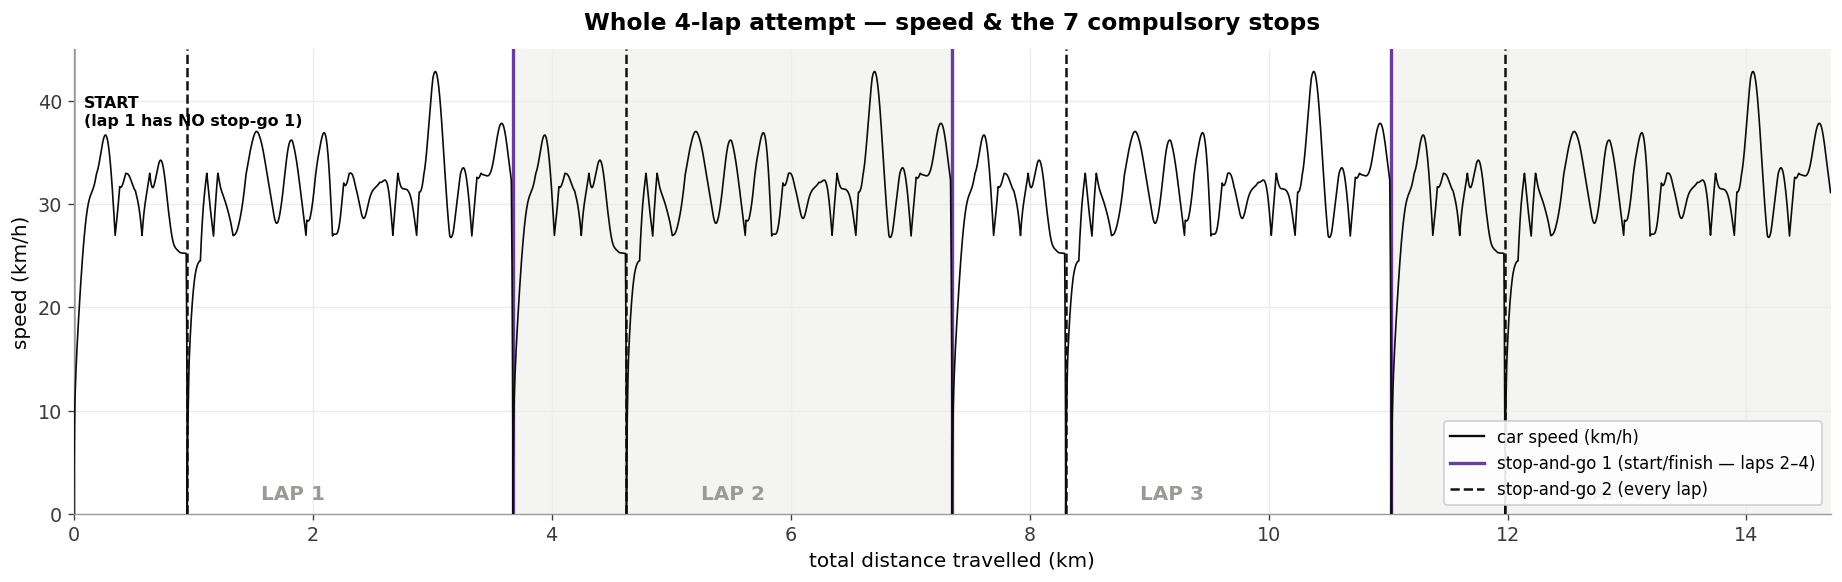

In [2]:
fig, ax = plt.subplots(figsize=(15.5, 5))
for lap in sorted(df.lap.unique()):
    seg = df[df.lap == lap]
    if lap % 2 == 0:
        ax.axvspan(seg.distance_km.min(), seg.distance_km.max(), color="#f4f4f2", zorder=0)
    ax.text((seg.distance_km.min()+seg.distance_km.max())/2, ymax*0.03, f"LAP {lap}",
            ha="center", fontsize=12, fontweight="bold", color="#9a9a95")
ax.plot(df.distance_km, df.v_kmh, color="#0b0b0b", lw=1.0, zorder=3)
for _, r in df[df.stop_label == "stop-and-go 1"].iterrows():
    ax.axvline(r.distance_km, color=SG1_C, lw=2.0)
for _, r in df[df.stop_label == "stop-and-go 2"].iterrows():
    ax.axvline(r.distance_km, color=SG2_C, ls="--", lw=1.5)
ax.axvline(0, color="#9a9a95", lw=1.5)
ax.annotate("START\n(lap 1 has NO stop-go 1)", (0, ymax*0.9), xytext=(6, 0),
            textcoords="offset points", fontsize=9.5, fontweight="bold", va="top")
ax.set_xlim(0, df.distance_km.max()); ax.set_ylim(0, ymax)
ax.set_xlabel("total distance travelled (km)"); ax.set_ylabel("speed (km/h)")
ax.set_title("Whole 4-lap attempt — speed & the 7 compulsory stops")
ax.legend(handles=[Line2D([0],[0],color="#0b0b0b",lw=1.4,label="car speed (km/h)"),
                   Line2D([0],[0],color=SG1_C,lw=2.0,label="stop-and-go 1 (start/finish — laps 2–4)"),
                   Line2D([0],[0],color=SG2_C,ls="--",lw=1.5,label="stop-and-go 2 (every lap)")],
          loc="lower right", framealpha=0.9)
plt.tight_layout(); plt.show()

## 2 · Track maps — a steady lap (motor & speed), both stop-and-gos shown

A representative lap (the car does this 3×). **Left:** coloured by motor. **Right:** by speed.
Purple ★ = stop-and-go 1 (start/finish), black ★ = stop-and-go 2.

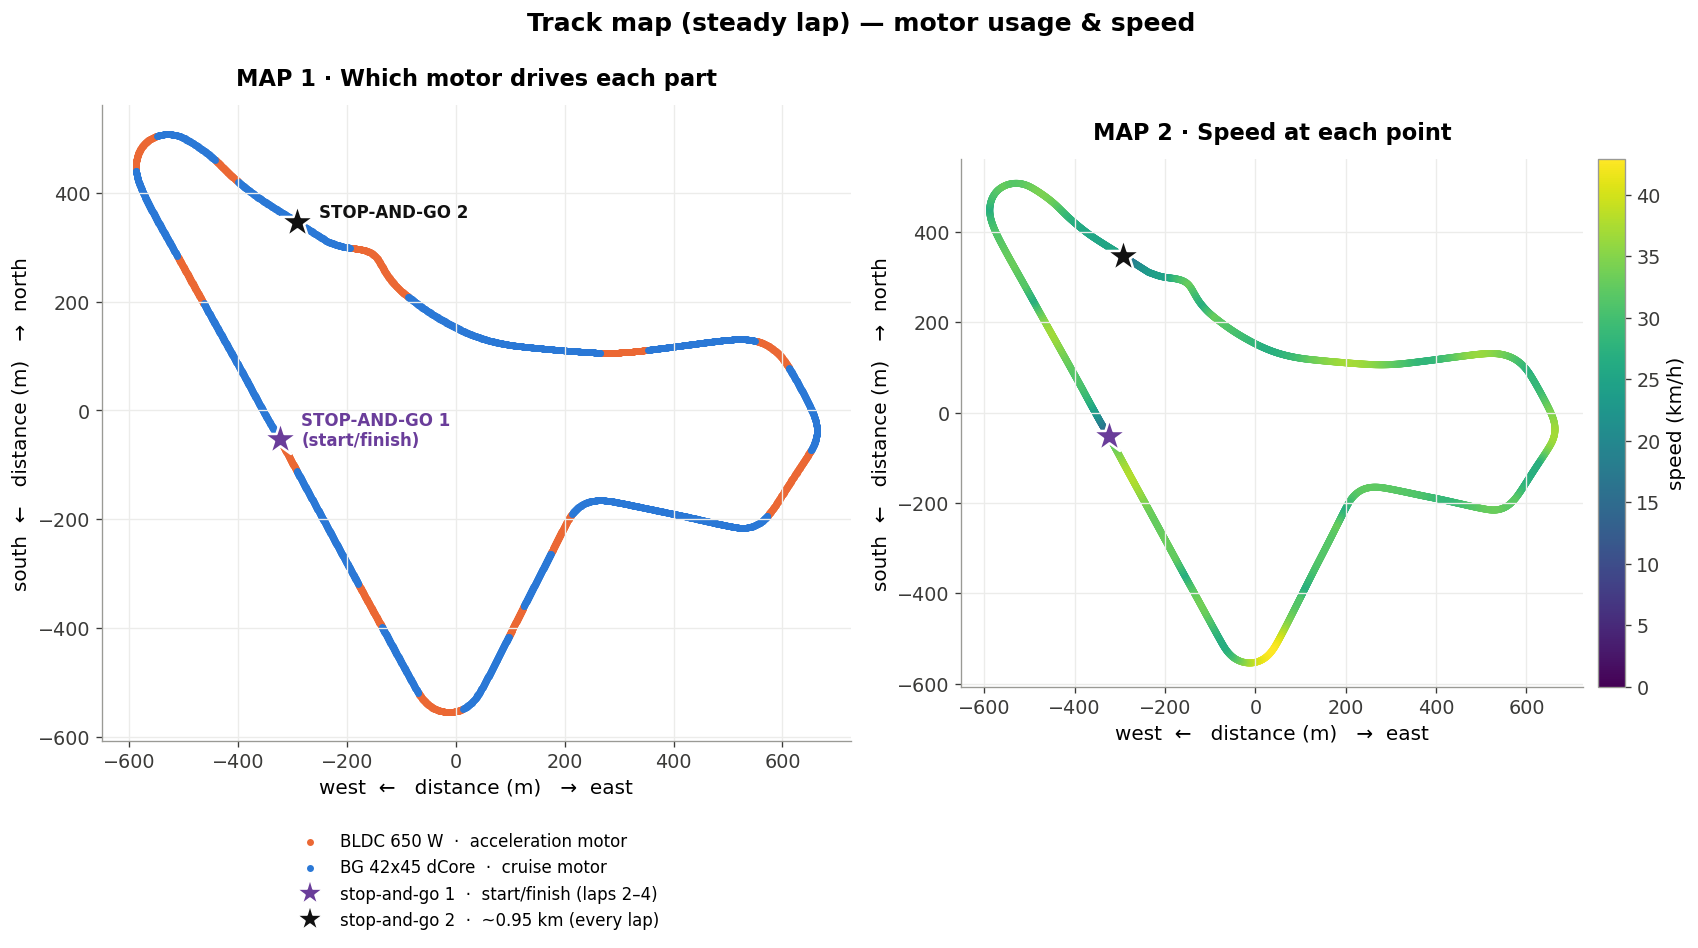

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14.5, 7))
for name, c in MOTOR_COLORS.items():
    m = steady["active_motor"] == name
    ax1.scatter(steady.x_m[m], steady.y_m[m], s=10, c=c, label=MOTOR_LABEL[name])
mark_stops_map(ax1)
ax1.set_aspect("equal"); ax1.set_title("MAP 1 · Which motor drives each part", fontsize=13.5)
ax1.set_xlabel("west  ←   distance (m)   →  east"); ax1.set_ylabel("south  ←   distance (m)   →  north")
h, l = ax1.get_legend_handles_labels()
ax1.legend(h + SG_HANDLES, l + [x.get_label() for x in SG_HANDLES],
           loc="lower center", bbox_to_anchor=(0.5, -0.32), frameon=False, ncol=1)

sc = ax2.scatter(steady.x_m, steady.y_m, s=10, c=steady.v_kmh, cmap="viridis")
mark_stops_map(ax2, annotate=False)
ax2.set_aspect("equal"); ax2.set_title("MAP 2 · Speed at each point", fontsize=13.5)
ax2.set_xlabel("west  ←   distance (m)   →  east"); ax2.set_ylabel("south  ←   distance (m)   →  north")
cb = fig.colorbar(sc, ax=ax2, shrink=0.8, pad=0.02); cb.set_label("speed (km/h)")
fig.suptitle("Track map (steady lap) — motor usage & speed", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

## 3 · Speed & active motor — steady lap

One representative lap. The car **launches from stop-and-go 1** on the orange BLDC, cruises on the
blue BG, does **stop-and-go 2** at ~0.95 km, then approaches the next lap's stop-and-go 1 at the end.

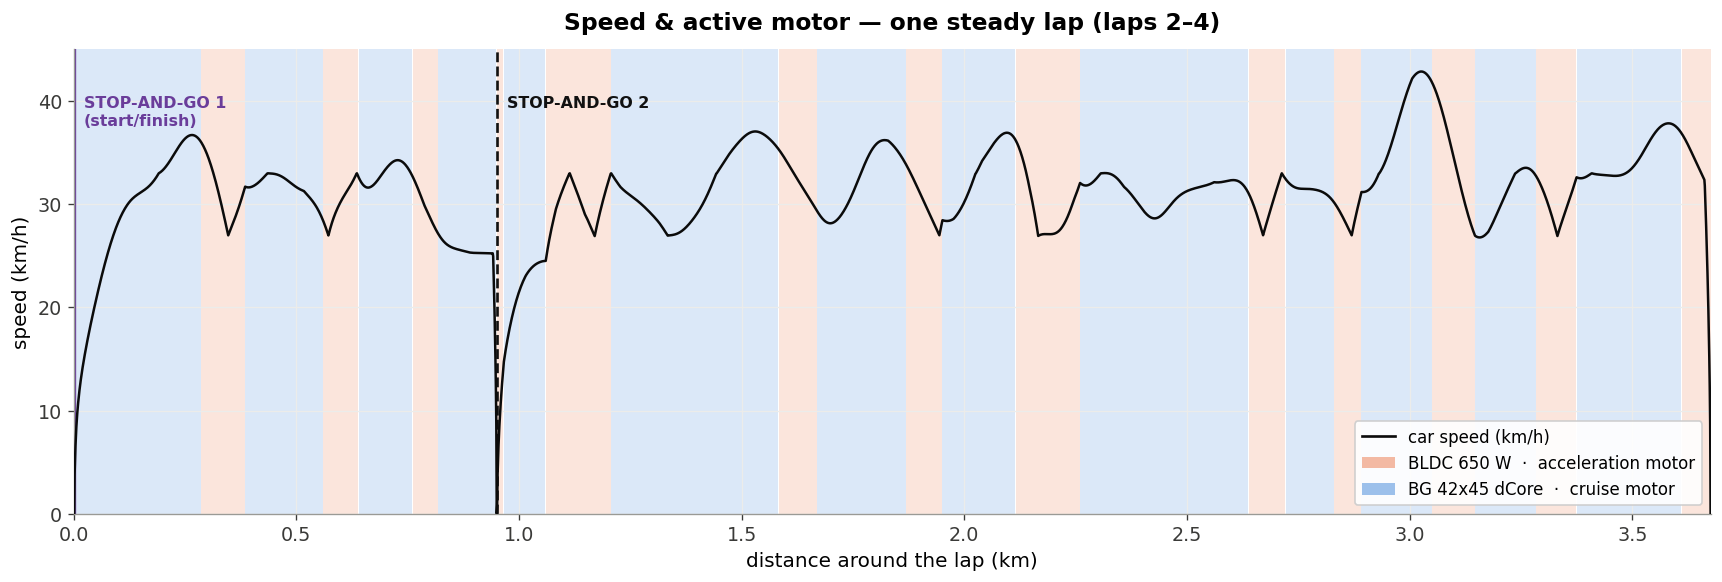

In [4]:
fig, ax = plt.subplots(figsize=(14.5, 5))
for name, c in MOTOR_COLORS.items():
    mask = (steady["active_motor"] == name).to_numpy()
    ax.fill_between(steady.lap_distance_km, 0, ymax, where=mask, color=c, alpha=0.17, lw=0)
ax.plot(steady.lap_distance_km, steady.v_kmh, color="#0b0b0b", lw=1.5, zorder=3)
ax.axvline(sg1.lap_distance_km.iloc[0], color=SG1_C, lw=2.0)
ax.annotate("STOP-AND-GO 1\n(start/finish)", (sg1.lap_distance_km.iloc[0], ymax*0.9), xytext=(6,0),
            textcoords="offset points", fontsize=9.5, fontweight="bold", color=SG1_C, va="top")
ax.axvline(sg2.lap_distance_km.iloc[0], color=SG2_C, ls="--", lw=1.6)
ax.annotate("STOP-AND-GO 2", (sg2.lap_distance_km.iloc[0], ymax*0.9), xytext=(6,0),
            textcoords="offset points", fontsize=9.5, fontweight="bold", color=SG2_C, va="top")
ax.set_xlim(0, steady.lap_distance_km.max()); ax.set_ylim(0, ymax)
ax.set_xlabel("distance around the lap (km)"); ax.set_ylabel("speed (km/h)")
ax.set_title("Speed & active motor — one steady lap (laps 2–4)")
handles = [Line2D([0],[0], color="#0b0b0b", lw=1.6, label="car speed (km/h)")]
handles += [Patch(facecolor=c, alpha=0.45, label=MOTOR_LABEL[n]) for n, c in MOTOR_COLORS.items()]
ax.legend(handles=handles, loc="lower right", framealpha=0.9)
plt.tight_layout(); plt.show()

## 4 · Gas-and-glide — steady lap

**Green = GAS** (motor ON). **Amber = GLIDE** (coasting). **Red = BRAKE**.

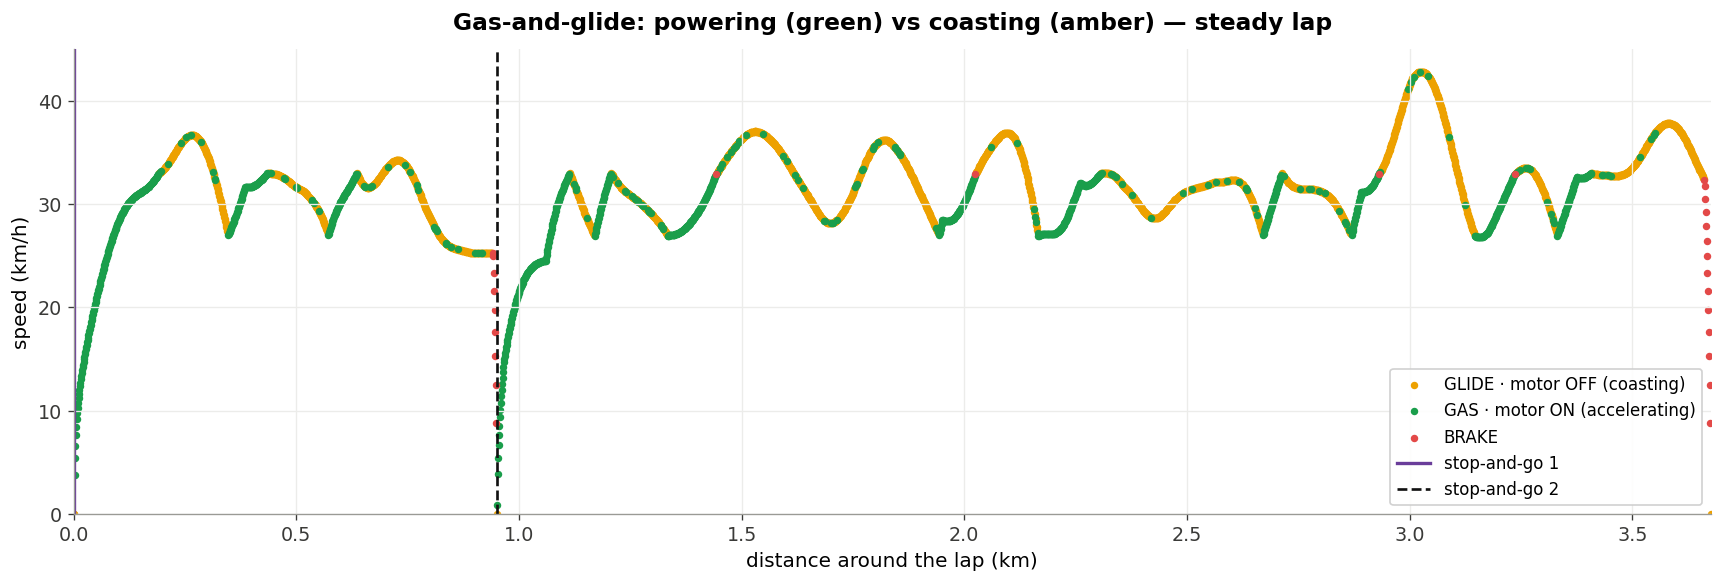

In [5]:
fig, ax = plt.subplots(figsize=(14.5, 5))
for ph in ["glide", "gas", "brake"]:
    if ph in steady.drive_phase.values:
        m = steady["drive_phase"] == ph
        ax.scatter(steady.lap_distance_km[m], steady.v_kmh[m], s=12, c=PHASE_COLORS[ph], label=PHASE_LABEL[ph])
ax.axvline(sg1.lap_distance_km.iloc[0], color=SG1_C, lw=2.0, label="stop-and-go 1")
ax.axvline(sg2.lap_distance_km.iloc[0], color=SG2_C, ls="--", lw=1.6, label="stop-and-go 2")
ax.set_xlim(0, steady.lap_distance_km.max()); ax.set_ylim(0, ymax)
ax.set_xlabel("distance around the lap (km)"); ax.set_ylabel("speed (km/h)")
ax.set_title("Gas-and-glide: powering (green) vs coasting (amber) — steady lap")
ax.legend(loc="lower right", framealpha=0.9)
plt.tight_layout(); plt.show()

## 5 · Track map — WHERE to gas vs glide (steady lap)

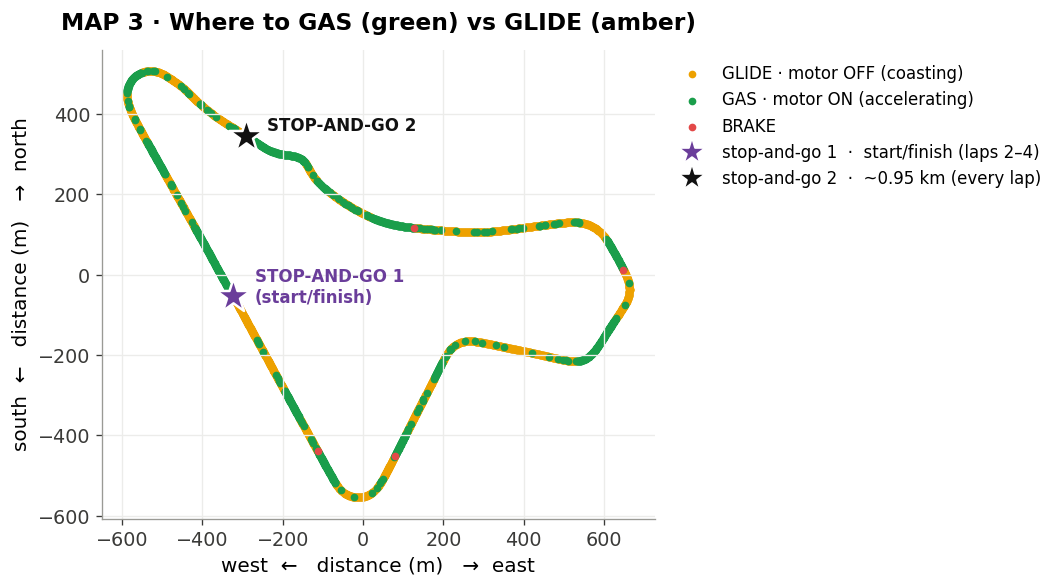

In [6]:
fig, ax = plt.subplots(figsize=(9, 8))
for ph in ["glide", "gas", "brake"]:
    if ph in steady.drive_phase.values:
        m = steady["drive_phase"] == ph
        ax.scatter(steady.x_m[m], steady.y_m[m], s=13, c=PHASE_COLORS[ph], label=PHASE_LABEL[ph])
mark_stops_map(ax)
ax.set_aspect("equal")
ax.set_title("MAP 3 · Where to GAS (green) vs GLIDE (amber)")
ax.set_xlabel("west  ←   distance (m)   →  east"); ax.set_ylabel("south  ←   distance (m)   →  north")
h, l = ax.get_legend_handles_labels()
ax.legend(h + SG_HANDLES, l + [x.get_label() for x in SG_HANDLES],
          loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False)
plt.tight_layout(); plt.show()

## 6 · Elevation & slope (steady lap) — why the accel motor turns on where it does

Orange bands = BLDC accel motor engaged; they line up with the climbs and the launches out of the stops.

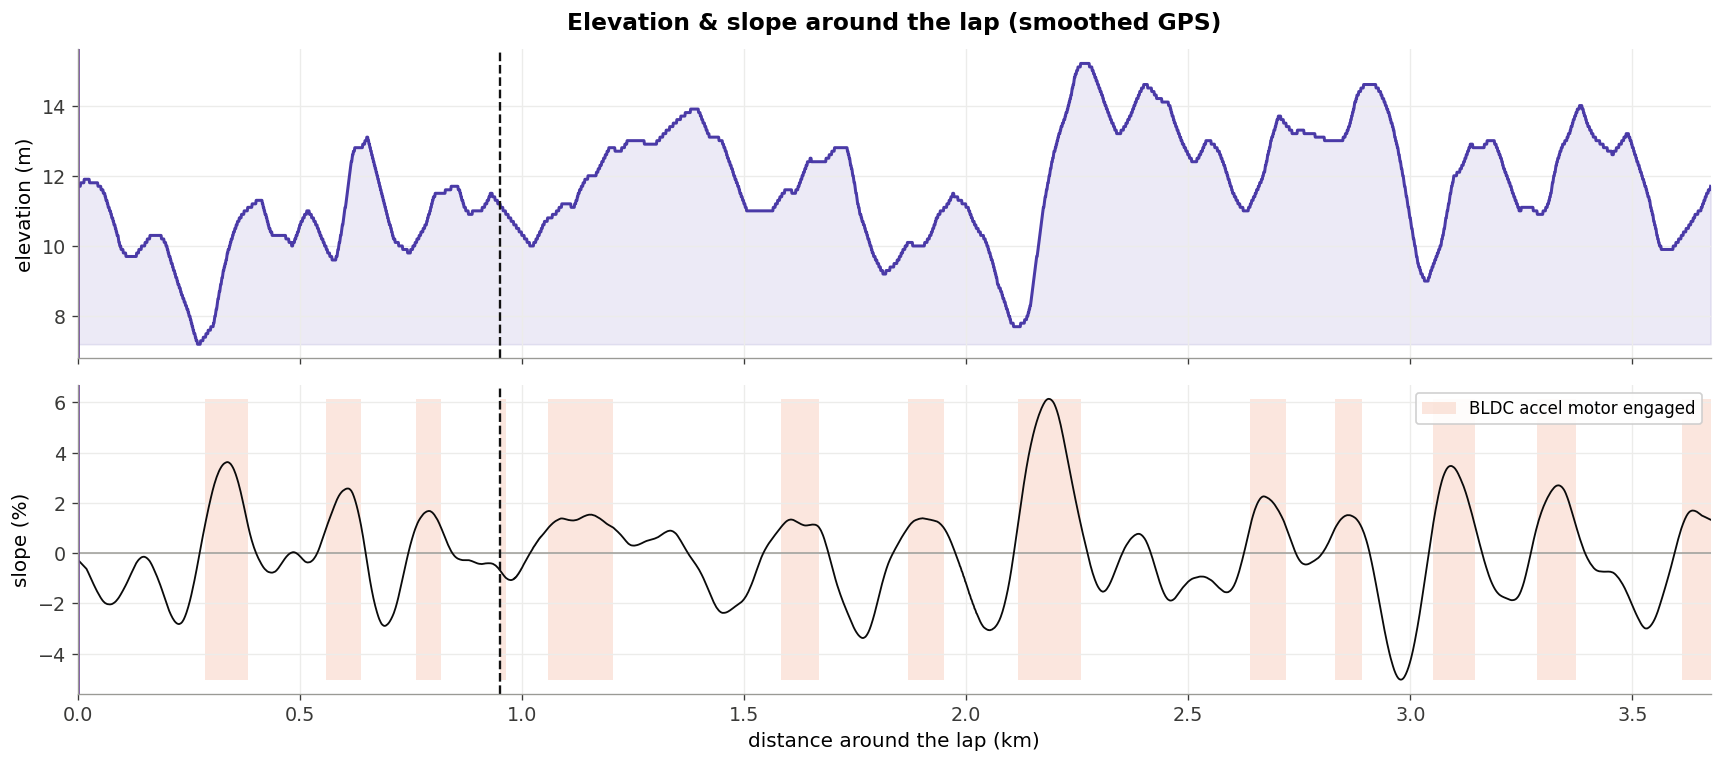

In [7]:
fig, (axa, axb) = plt.subplots(2, 1, figsize=(14.5, 6.5), sharex=True)
axa.plot(steady.lap_distance_km, steady.altitude_m, color="#4a3aa7", lw=1.8)
axa.fill_between(steady.lap_distance_km, steady.altitude_m.min(), steady.altitude_m, color="#4a3aa7", alpha=0.10)
axa.set_ylabel("elevation (m)"); axa.set_title("Elevation & slope around the lap (smoothed GPS)")
axb.axhline(0, color="#9a9a95", lw=0.9)
axb.plot(steady.lap_distance_km, steady.grade_pct, color="#0b0b0b", lw=1.1)
mask = (steady["active_motor"] == "BLDC 650W").to_numpy()
axb.fill_between(steady.lap_distance_km, steady.grade_pct.min(), steady.grade_pct.max(),
                 where=mask, color="#eb6834", alpha=0.16, lw=0, label="BLDC accel motor engaged")
axb.set_ylabel("slope (%)"); axb.set_xlabel("distance around the lap (km)")
axb.legend(loc="upper right", framealpha=0.9)
for ax in (axa, axb):
    ax.axvline(sg1.lap_distance_km.iloc[0], color=SG1_C, lw=1.6)
    ax.axvline(sg2.lap_distance_km.iloc[0], color=SG2_C, ls="--", lw=1.4)
ax.set_xlim(0, steady.lap_distance_km.max())
plt.tight_layout(); plt.show()

## 7 · Summary shares (whole attempt)

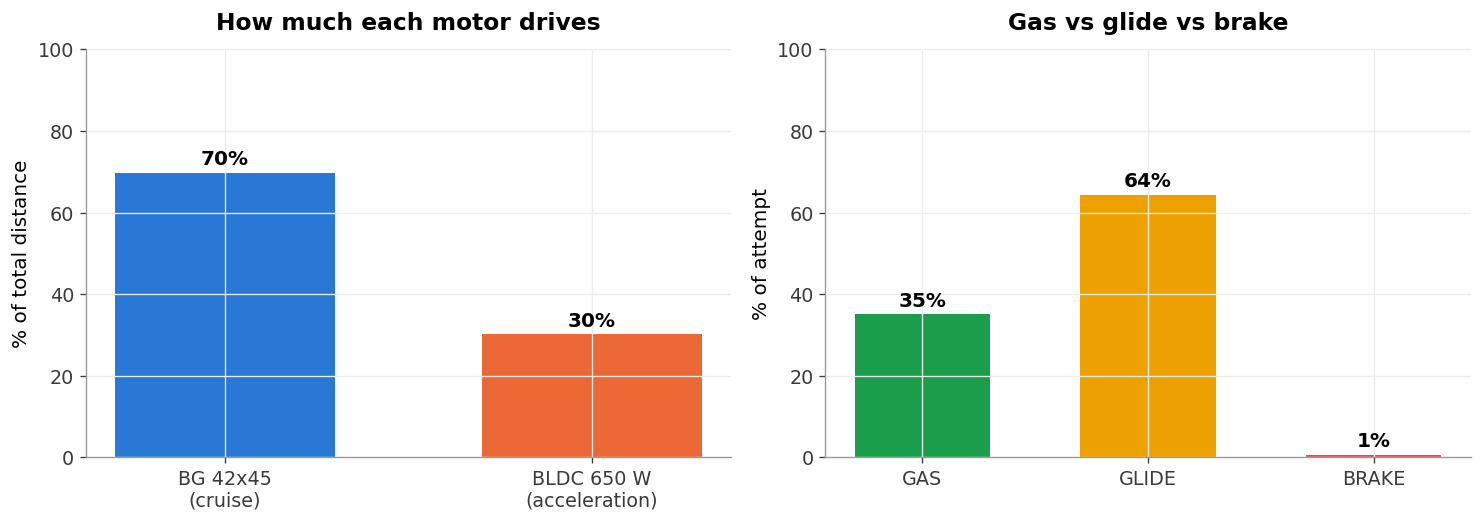

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.5))
share = df["active_motor"].value_counts()
names = ["BLDC 650 W\n(acceleration)" if "BLDC" in n else "BG 42x45\n(cruise)" for n in share.index]
ax1.bar(names, share.values/len(df)*100, color=[MOTOR_COLORS[n] for n in share.index], width=0.6)
ax1.set_ylabel("% of total distance"); ax1.set_title("How much each motor drives"); ax1.set_ylim(0,100)
for i, v in enumerate(share.values/len(df)*100): ax1.text(i, v+2, f"{v:.0f}%", ha="center", fontweight="bold", fontsize=12)
order = [p for p in ["gas","glide","brake"] if p in df.drive_phase.values]
phc = df["drive_phase"].value_counts().reindex(order)
ax2.bar([p.upper() for p in order], phc.values/len(df)*100, color=[PHASE_COLORS[p] for p in order], width=0.6)
ax2.set_ylabel("% of attempt"); ax2.set_title("Gas vs glide vs brake"); ax2.set_ylim(0,100)
for i, v in enumerate(phc.values/len(df)*100): ax2.text(i, v+2, f"{v:.0f}%", ha="center", fontweight="bold", fontsize=12)
plt.tight_layout(); plt.show()

In [9]:
clip = int(df.motor_clipped.sum()); bg = (df.active_motor=='BG 42x45 dCore').mean()*100
print(f'BG cruise motor : {bg:.0f}% of attempt   |   BLDC accel motor : {100-bg:.0f}%')
print(f'gliding/coasting: {(df.drive_phase=="glide").mean()*100:.0f}% of attempt')
print(f'stops           : {df.stop_event.sum()} flagged | 7 are real 3s stop-and-gos (lap 1 has no stop-go 1)')
print(f'power-limited   : {clip} of {len(df)} points ({clip/len(df)*100:.0f}%)')

BG cruise motor : 70% of attempt   |   BLDC accel motor : 30%
gliding/coasting: 64% of attempt
stops           : 8 flagged | 7 are real 3s stop-and-gos (lap 1 has no stop-go 1)
power-limited   : 4468 of 14708 points (30%)


## Where the data comes from

Produced by the digital-twin simulator (`digital_twin/simulate.py`), run for the full 4-lap attempt.

| What | Source | Notes |
|---|---|---|
| Track shape, GPS coords, elevation, slope | `data/sem_apme_2025-track_coordinates.csv` | Lusail GPS trace; `track.py` derives heading & slope (**±50 m smoothed**). |
| Corner radii / turn zones | `data/turns.csv` | Safe cornering speed. |
| Track widths | `data/track_edges_imagery.csv` | — |
| BLDC 650 W curve | `data/motor_candidates.csv` | Digitised from `BLDC .png` dyno chart. |
| BG 42x45 dCore curve | `data/motor_candidates.csv` | From `BG 42x45 dCore.pdf` (efficiency partly estimated). |
| Fuel cell | `data/fc_candidates.csv` | → H2 use. |
| Mass / drag / rolling | `digital_twin/config.py` | 158 kg; CFD drag; assumed Crr. |
| Weather | `digital_twin/weather.py` | `typical_january`. |

**Stop rule modelled:** 2 stop-and-gos, 3 s each; stop-and-go 1 on the start/finish line (skipped on
lap 1's standing start), stop-and-go 2 at ~0.95 km every lap → 7 stops total.

**Caveats:** gas-and-glide band is a simple demo (real GA/PSO tunes it per segment); slope still ~6 %
(GPS residual); BG cruise motor is power-limited on some sections. Strategy guidance, not live control.